只计算ARI

In [2]:
# ===================== TUSCAN 计算并保存 ARI 指标 =====================
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import os
import warnings
from sklearn.metrics import adjusted_rand_score

warnings.filterwarnings("ignore")

# ==========================================
# 1. 修正数据路径
# ==========================================
TUSCAN_CSV_PATH = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/TUSCAN_Results/12_colorectal_cancer_CRC/SN84_A120838_Rep1/TUSCAN_ClusterLabels.csv"
H5AD_PATH = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad" 

# ==========================================
# 2. 读取与清洗数据
# ==========================================
print("===== 加载与对齐数据 =====")
adata = ad.read_h5ad(H5AD_PATH)
tuscan_labels = pd.read_csv(TUSCAN_CSV_PATH, index_col="Spot_Barcode")

# 还原 R 语言修改的 Barcode 格式 (将 '.' 替换回 '-')
tuscan_labels.index = tuscan_labels.index.str.replace('.', '-', regex=False)

# 合并标签
adata.obs = adata.obs.join(tuscan_labels, how="left")

# 检查匹配成功的 Spot 数量
matched_spots = adata.obs["TUSCAN_Tumor_Normal"].notna().sum()
print(f"🔗 成功匹配到 TUSCAN 预测结果的 Spot 数量: {matched_spots} / {adata.n_obs}")

if matched_spots == 0:
    raise ValueError("❌ 匹配失败！参与计算的 Spot 数量为 0，请检查 CSV 中的 Barcode 格式。")

adata = adata[adata.obs["TUSCAN_Tumor_Normal"].notna()].copy()

# ==========================================
# 3. 标签映射 (二分类：Invasive+Tumor vs Healthy+Surrounding tumor)
# ==========================================
# 真实标签映射
gt_map_int = {
     'tumor': 1,
    'tumor&stroma_IC low': 1,
    'tumor&stroma_IC med to high': 1,
    'stroma_fibroblastic_IC high': 1,
    'stroma_fibroblastic_IC low': 0,
    'stroma_fibroblastic_IC med': 0
}
pred_map = {'Tumor': 1, 'Normal': 0}

gt_labels_for_math = adata.obs['pathology_annotation'].map(gt_map_int).values

# 映射预测标签
if adata.obs['TUSCAN_Tumor_Normal'].dtype == object or adata.obs['TUSCAN_Tumor_Normal'].dtype.name == 'category':
    pred_labels = adata.obs['TUSCAN_Tumor_Normal'].map(pred_map).values
else:
    pred_labels = adata.obs['TUSCAN_Tumor_Normal'].values

# ==========================================
# 4. 计算 ARI
# ==========================================
valid_mask = ~np.isnan(gt_labels_for_math) & ~np.isnan(pred_labels)
y_true = gt_labels_for_math[valid_mask]
y_pred = pred_labels[valid_mask]

print(f"📊 最终有效参与 ARI 计算的 Spot 数量: {len(y_true)}")

if len(y_true) > 0:
    ari_val = adjusted_rand_score(y_true, y_pred)
    print("\n" + "="*50)
    print(f"✅ TUSCAN 模型前列腺癌分割 ARI 指标：{ari_val:.4f}")
    print("="*50)
    
    # ==========================================
    # 5. 保存结果到指定目录
    # ==========================================
    SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/TUSCAN"
    os.makedirs(SAVE_DIR, exist_ok=True)
    csv_save_path = os.path.join(SAVE_DIR, "TUSCAN_ARI.csv")

    results_df = pd.DataFrame({
        "Metric Name": ["Adjusted Rand Index"],
        "Abbreviation": ["ARI"],
        "Value": [round(ari_val, 4)],
        "Ideal Trend": ["Closer to 1"],
        "Evaluation Dimension": ["Macro Boundary (Supervised)"]
    })

    results_df.to_csv(csv_save_path, index=False, encoding="utf-8-sig")

    print(f"\n🎉 TUSCAN 评估结果已成功保存至：\n   {csv_save_path}")
    display(results_df)

else:
    print("❌ 有效计算数据为空，无法得出真实 ARI。")

===== 加载与对齐数据 =====
🔗 成功匹配到 TUSCAN 预测结果的 Spot 数量: 240 / 240
📊 最终有效参与 ARI 计算的 Spot 数量: 240

✅ TUSCAN 模型前列腺癌分割 ARI 指标：-0.0119

🎉 TUSCAN 评估结果已成功保存至：
   /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/TUSCAN/TUSCAN_ARI.csv


,Metric Name,Abbreviation,Value,Ideal Trend,Evaluation Dimension
0,Adjusted Rand Index,ARI,-0.0119,Closer to 1,Macro Boundary (Supervised)


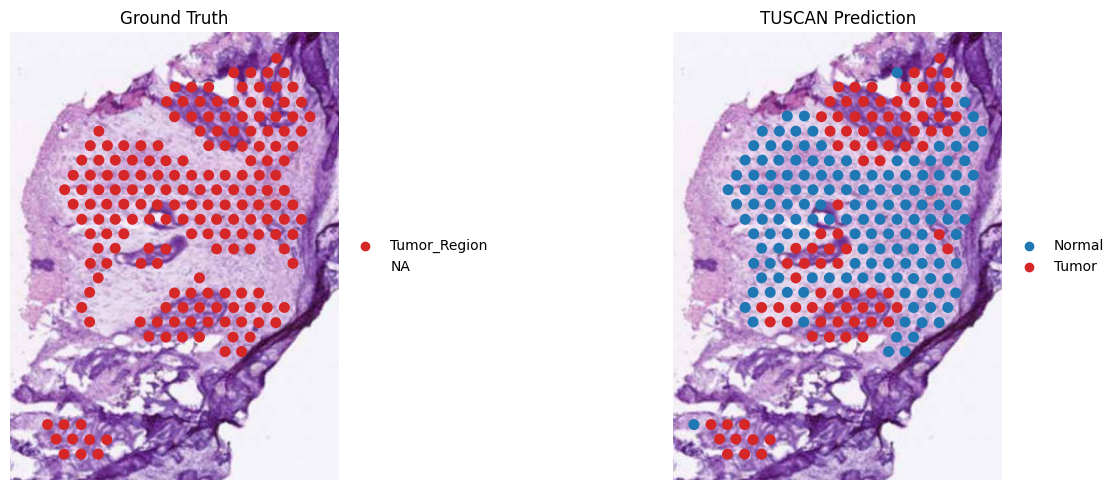

In [2]:
# ===================== TUSCAN 结果 + 病理标注并排可视化（不保存、不改原文件） =====================
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

TUSCAN_CSV_PATH = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/TUSCAN_Results/12_colorectal_cancer_CRC/SN84_A120838_Rep1/TUSCAN_ClusterLabels.csv"
H5AD_PATH = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad"

adata = ad.read_h5ad(H5AD_PATH)
tuscan_labels = pd.read_csv(TUSCAN_CSV_PATH, index_col="Spot_Barcode")
tuscan_labels.index = tuscan_labels.index.str.replace(".", "-", regex=False)

adata.obs = adata.obs.join(tuscan_labels, how="left")

if adata.obs["TUSCAN_Tumor_Normal"].notna().sum() == 0:
    raise ValueError("❌ 没有匹配到任何 TUSCAN spot，请检查 barcode 格式。")

adata_plot = adata[adata.obs["TUSCAN_Tumor_Normal"].notna()].copy()
adata_plot.obs["TUSCAN_Tumor_Normal"] = adata_plot.obs["TUSCAN_Tumor_Normal"].astype("category")

# 病理标注二分类映射
gt_map_str = {
    'tumor': 'Tumor_Region',
    'tumor&stroma_IC med to high': 'Tumor_Region',
    'stroma_fibroblastic_IC high': 'Tumor_Region',
    'epithelium&submucosa': 'Non_Tumor_Region',
    'non neo epithelium': 'Non_Tumor_Region',
    'submucosa': 'Non_Tumor_Region',
    'IC aggregregate_submucosa': 'Non_Tumor_Region'
}

adata_plot.obs["Ground_Truth_Binary"] = (
    adata_plot.obs["pathology_annotation"]
    .map(gt_map_str)
    .astype("category")
)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.spatial(
    adata_plot,
    color="Ground_Truth_Binary",
    palette={"Tumor_Region": "#d62728", "Non_Tumor_Region": "#1f77b4"},
    size=1,
    title="Ground Truth",
    frameon=False,
    ax=axs[0],
    show=False
)

sc.pl.spatial(
    adata_plot,
    color="TUSCAN_Tumor_Normal",
    palette={"Tumor": "#d62728", "Normal": "#1f77b4"},
    size=1,
    title="TUSCAN Prediction",
    frameon=False,
    ax=axs[1],
    show=False
)

plt.tight_layout()
plt.show()